# 📊 Notebook 1 — Synthetic Data Generation

## Coal Demand Forecasting Project (CRISP-ML(Q) Framework)

**Objective:** Generate 3 years (2022-2024) of realistic synthetic daily coal demand data for an Indian thermal power plant.

### What this notebook does:
1. Generates 1,096 days of daily data with realistic seasonal patterns
2. Includes Indian public holidays, weekday/weekend variation, and temperature cycles
3. Derives coal consumption from power generation using an efficiency factor
4. Simulates inventory levels with reorder logic
5. Injects controlled missing values (~5%) and outliers (~3%) for realistic data quality issues
6. Saves the raw dataset to `data/raw/coal_data.csv`

---

## 1.1 Setup & Imports

In [1]:
import os, sys
# Add project root to path so we can import src modules
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

from src.config import (
    DATA_START_DATE, DATA_END_DATE, BASE_POWER_MW, EFFICIENCY_FACTOR,
    MISSING_VALUE_FRACTION, OUTLIER_FRACTION, RAW_DATA_FILE
)

print(f"Project Root: {PROJECT_ROOT}")
print(f"Date Range: {DATA_START_DATE} → {DATA_END_DATE}")
print(f"Base Power: {BASE_POWER_MW} MW")
print(f"Efficiency Factor: {EFFICIENCY_FACTOR}")
print(f"Missing Value Fraction: {MISSING_VALUE_FRACTION*100:.0f}%")
print(f"Outlier Fraction: {OUTLIER_FRACTION*100:.0f}%")

Project Root: /Users/palasudeepkumar/Desktop/Foundation_Project/coal-demand-forecasting
Date Range: 2022-01-01 → 2024-12-31
Base Power: 500.0 MW
Efficiency Factor: 0.45
Missing Value Fraction: 5%
Outlier Fraction: 3%


## 1.2 Generate Synthetic Data

The `generate_data()` function creates all features:
- **power_generation_mw** — Power output with summer/winter peaks, weekend dips, holiday effects
- **coal_consumption_tonnes** — Derived from power generation × efficiency factor + noise
- **temperature_c** — Indian seasonal temperature curve (peak ~May, low ~Jan)
- **coal_price_inr** — Coal prices with upward trend and volatility (₹8,000–₹14,000)
- **inventory_level_tonnes** — Simulated with reorder point logic
- **is_holiday** — Indian public holidays (Republic Day, Holi, Diwali, etc.)
- **is_weekend** — Saturday/Sunday flag

In [2]:
from src.data_generator import generate_data

# Generate the dataset
df = generate_data()

print(f"\n{'='*60}")
print(f"  GENERATED DATASET SUMMARY")
print(f"{'='*60}")
print(f"  Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"  Date Range: {df['date'].min()} → {df['date'].max()}")
print(f"  Columns: {list(df.columns)}")

[2026-03-02 18:26:02] [INFO] [data] Starting synthetic data generation...
[2026-03-02 18:26:02] [INFO] [data] Generating 1096 days of data from 2022-01-01 to 2024-12-31
[2026-03-02 18:26:02] [INFO] [data] Raw data shape: (1096, 8)
[2026-03-02 18:26:02] [INFO] [data] Missing values per column (%):
[2026-03-02 18:26:02] [INFO] [data]   power_generation_mw: 0.91%
[2026-03-02 18:26:02] [INFO] [data]   coal_consumption_tonnes: 0.91%
[2026-03-02 18:26:02] [INFO] [data]   temperature_c: 0.91%
[2026-03-02 18:26:02] [INFO] [data]   coal_price_inr: 0.91%
[2026-03-02 18:26:02] [INFO] [data]   inventory_level_tonnes: 0.91%
[2026-03-02 18:26:02] [INFO] [data] Injected ~3% outliers into key columns
[2026-03-02 18:26:02] [INFO] [data] Data saved to /Users/palasudeepkumar/Desktop/Foundation_Project/coal-demand-forecasting/data/raw/coal_data.csv
[2026-03-02 18:26:02] [INFO] [data] Column statistics:
[2026-03-02 18:26:02] [INFO] [data]   power_generation_mw: mean=539.11, std=127.98, min=303.15, max=1800

## 1.3 Preview the Raw Data

Let's examine the first and last few rows of the generated dataset.

In [3]:
print("First 10 rows:")
display(df.head(10))

print("\nLast 5 rows:")
display(df.tail(5))

First 10 rows:


,date,power_generation_mw,coal_consumption_tonnes,temperature_c,coal_price_inr,inventory_level_tonnes,is_holiday,is_weekend
0,2022-01-01,499.51,228.14,7.5,8000.00,5000.00,0,1
1,2022-01-02,509.94,239.60,12.2,8000.00,4760.40,0,1
2,2022-01-03,582.67,252.07,6.0,8000.00,4508.34,0,0
3,2022-01-04,571.25,264.05,13.1,8000.00,4244.29,0,0
4,2022-01-05,593.46,275.36,10.3,8012.59,3968.93,0,0
5,2022-01-06,586.27,229.09,10.2,8000.00,3739.83,0,0
6,2022-01-07,596.21,273.23,7.4,8000.00,3466.61,0,0
7,2022-01-08,507.25,204.28,8.7,8000.00,3262.33,0,1
8,2022-01-09,490.00,243.55,9.4,8038.21,NaN,0,1
9,2022-01-10,572.34,245.11,8.9,8091.92,2773.66,0,0



Last 5 rows:


,date,power_generation_mw,coal_consumption_tonnes,temperature_c,coal_price_inr,inventory_level_tonnes,is_holiday,is_weekend
1091,2024-12-27,572.93,275.38,9.7,10772.41,1831.61,0,0
1092,2024-12-28,500.70,217.10,9.0,10833.17,4614.51,0,1
1093,2024-12-29,480.09,227.46,10.3,10802.49,4387.05,0,1
1094,2024-12-30,584.66,260.98,9.7,10863.75,4126.07,0,0
1095,2024-12-31,551.87,253.68,15.2,10887.49,3872.39,0,0


## 1.4 Descriptive Statistics

Summary statistics for all numeric columns — mean, std, min/max, and quartiles.

In [4]:
display(df.describe().round(2))

,date,power_generation_mw,coal_consumption_tonnes,temperature_c,coal_price_inr,inventory_level_tonnes,is_holiday,is_weekend
count,1096,1086.00,1086.00,1086.00,1086.00,1086.00,1096.00,1096.00
mean,2023-07-02 12:00:00,539.11,243.63,24.98,9764.71,3250.05,0.04,0.29
min,2022-01-01 00:00:00,303.15,131.04,5.00,8000.00,1748.20,0.00,0.00
25%,2022-10-01 18:00:00,492.26,218.08,15.00,8535.49,2502.00,0.00,0.00
50%,2023-07-02 12:00:00,532.83,240.08,24.80,10089.04,3243.78,0.00,0.00
75%,2024-04-01 06:00:00,572.29,259.76,35.40,10853.32,3998.40,0.00,1.00
max,2024-12-31 00:00:00,1800.96,795.72,44.90,11735.22,5000.00,1.00,1.00
std,NaN,127.98,64.13,10.89,1181.34,870.18,0.19,0.45


## 1.5 Data Quality Check — Missing Values & Data Types

In [5]:
print("Data Types:")
print(df.dtypes.to_string())

print(f"\n{'='*50}")
print("Missing Values:")
print(f"{'='*50}")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0]
if len(missing_df) > 0:
    display(missing_df)
else:
    print("No missing values found.")

print(f"\nTotal missing cells: {df.isnull().sum().sum()} / {df.shape[0] * df.shape[1]}")

Data Types:
date                       datetime64[ns]
power_generation_mw               float64
coal_consumption_tonnes           float64
temperature_c                     float64
coal_price_inr                    float64
inventory_level_tonnes            float64
is_holiday                          int64
is_weekend                          int64

Missing Values:


,Count,Percentage
power_generation_mw,10,0.91
coal_consumption_tonnes,10,0.91
temperature_c,10,0.91
coal_price_inr,10,0.91
inventory_level_tonnes,10,0.91



Total missing cells: 50 / 8768


## 1.6 Quick Visualization — Raw Data Overview

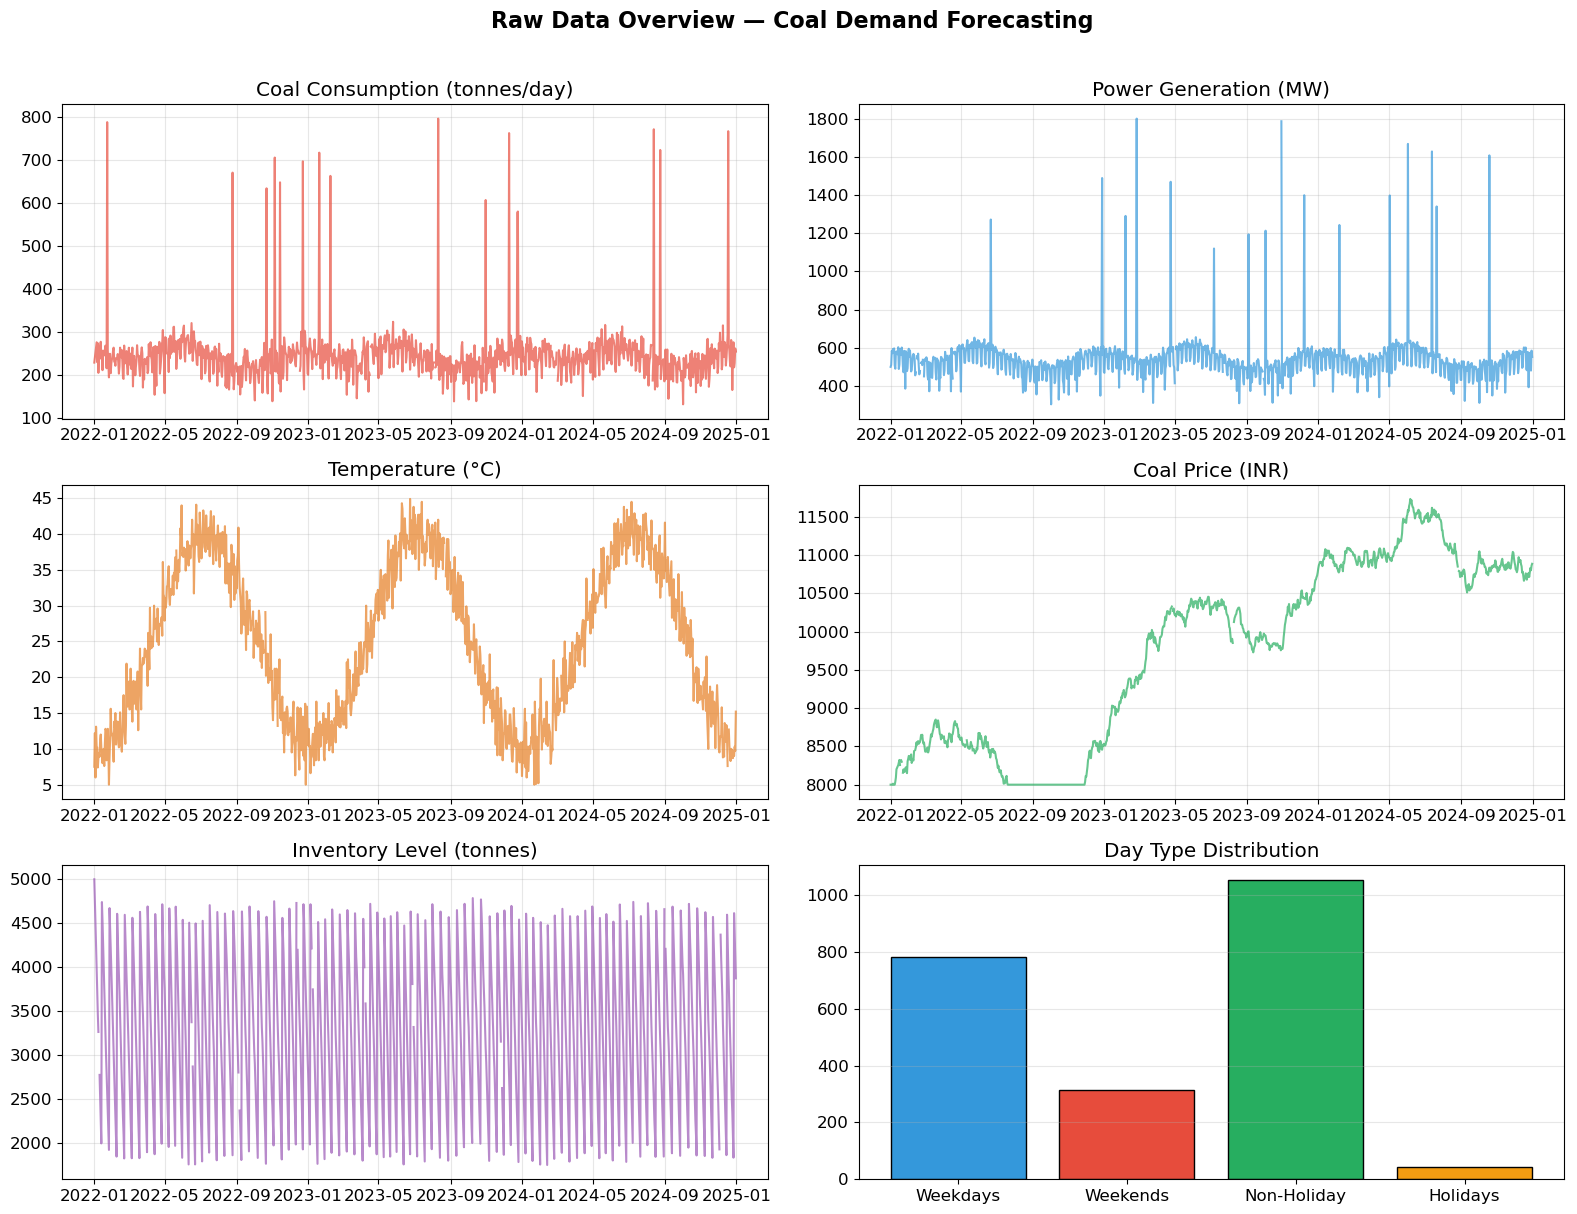


✅ Data generation complete — 1096 rows saved to /Users/palasudeepkumar/Desktop/Foundation_Project/coal-demand-forecasting/data/raw/coal_data.csv


In [6]:
df_plot = df.copy()
df_plot['date'] = pd.to_datetime(df_plot['date'])

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Raw Data Overview — Coal Demand Forecasting', fontsize=16, fontweight='bold', y=1.01)

# Coal consumption
axes[0, 0].plot(df_plot['date'], df_plot['coal_consumption_tonnes'], color='#E74C3C', alpha=0.7)
axes[0, 0].set_title('Coal Consumption (tonnes/day)')
axes[0, 0].grid(True, alpha=0.3)

# Power generation
axes[0, 1].plot(df_plot['date'], df_plot['power_generation_mw'], color='#3498DB', alpha=0.7)
axes[0, 1].set_title('Power Generation (MW)')
axes[0, 1].grid(True, alpha=0.3)

# Temperature
axes[1, 0].plot(df_plot['date'], df_plot['temperature_c'], color='#E67E22', alpha=0.7)
axes[1, 0].set_title('Temperature (°C)')
axes[1, 0].grid(True, alpha=0.3)

# Coal price
axes[1, 1].plot(df_plot['date'], df_plot['coal_price_inr'], color='#27AE60', alpha=0.7)
axes[1, 1].set_title('Coal Price (INR)')
axes[1, 1].grid(True, alpha=0.3)

# Inventory
axes[2, 0].plot(df_plot['date'], df_plot['inventory_level_tonnes'], color='#9B59B6', alpha=0.7)
axes[2, 0].set_title('Inventory Level (tonnes)')
axes[2, 0].grid(True, alpha=0.3)

# Holidays/Weekends distribution
holiday_counts = df_plot['is_holiday'].value_counts()
weekend_counts = df_plot['is_weekend'].value_counts()
categories = ['Weekdays', 'Weekends', 'Non-Holiday', 'Holidays']
values = [
    weekend_counts.get(0, 0), weekend_counts.get(1, 0),
    holiday_counts.get(0, 0), holiday_counts.get(1, 0)
]
colors = ['#3498DB', '#E74C3C', '#27AE60', '#F39C12']
axes[2, 1].bar(categories, values, color=colors, edgecolor='black')
axes[2, 1].set_title('Day Type Distribution')
axes[2, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n✅ Data generation complete — {len(df)} rows saved to {RAW_DATA_FILE}")